In [1]:
import scipy.io as sio
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import joblib

/opt/anaconda3/envs/188/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## __LOADING DATA / EXPLORING + SEPARATING NEEDED PARTS__

In [2]:
# Download latest version
path = kagglehub.dataset_download("mansibmursalin/ninapro-db1-full-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/avatarvaleria/.cache/kagglehub/datasets/mansibmursalin/ninapro-db1-full-dataset/versions/1


In [3]:
#/Users/avatarvaleria/.cache/kagglehub/datasets/mansibmursalin/ninapro-db1-full-dataset/versions/1
print(path)
print(os.path.exists(path))
print(os.listdir(path))

/Users/avatarvaleria/.cache/kagglehub/datasets/mansibmursalin/ninapro-db1-full-dataset/versions/1
True
['Ninapro_DB1.csv']


In [4]:
dataset = pd.read_csv(
    "/Users/avatarvaleria/.cache/kagglehub/datasets/mansibmursalin/ninapro-db1-full-dataset/versions/1/Ninapro_DB1.csv"
)
print(dataset.head)

<bound method NDFrame.head of           Unnamed: 0   emg_0   emg_1   emg_2   emg_3   emg_4   emg_5   emg_6  \
0                  0  0.0024  0.0024  0.0024  0.0024  0.0024  0.0098  0.0146   
1                  1  0.0024  0.0024  0.0024  0.0024  0.0024  0.0098  0.0122   
2                  2  0.0024  0.0024  0.0024  0.0024  0.0024  0.0073  0.0073   
3                  3  0.0049  0.0024  0.0024  0.0024  0.0024  0.0073  0.0049   
4                  4  0.0049  0.0024  0.0024  0.0024  0.0024  0.0024  0.0024   
...              ...     ...     ...     ...     ...     ...     ...     ...   
12553606      217538  0.0024  0.0024  0.0024  0.0024  0.0024  0.0342  0.0854   
12553607      217539  0.0024  0.0024  0.0024  0.0024  0.0024  0.0464  0.0757   
12553608      217540  0.0024  0.0024  0.0024  0.0024  0.0024  0.0537  0.0635   
12553609      217541  0.0024  0.0024  0.0024  0.0024  0.0024  0.0586  0.0562   
12553610      217542  0.0024  0.0024  0.0024  0.0024  0.0024  0.0635  0.0464   

         

In [5]:
print(dataset.columns)

Index(['Unnamed: 0', 'emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5',
       'emg_6', 'emg_7', 'emg_8', 'emg_9', 'glove_0', 'glove_1', 'glove_2',
       'glove_3', 'glove_4', 'glove_5', 'glove_6', 'glove_7', 'glove_8',
       'glove_9', 'glove_10', 'glove_11', 'glove_12', 'glove_13', 'glove_14',
       'glove_15', 'glove_16', 'glove_17', 'glove_18', 'glove_19', 'glove_20',
       'glove_21', 'exercise', 'stimulus', 'restimulus', 'repetition',
       'rerepetition', 'subject'],
      dtype='object')


In [6]:
exercise2_df = dataset[dataset["exercise"] == 2]
exercise2_df.iloc[:3]

,Unnamed: 0,emg_0,emg_1,emg_2,emg_3,emg_4,emg_5,emg_6,emg_7,emg_8,...,glove_18,glove_19,glove_20,glove_21,exercise,stimulus,restimulus,repetition,rerepetition,subject
100778,0,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0415,0.0708,0.0024,...,141.0,179.0,148.0,111.0,2,0,0,0,0,10
100779,1,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0366,0.0659,0.0024,...,141.0,179.0,148.0,111.0,2,0,0,0,0,10
100780,2,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0293,0.0684,0.0024,...,141.0,179.0,148.0,111.0,2,0,0,0,0,10


In [7]:
exercise2_df.shape

(3868568, 39)

In [8]:
new_dataset = exercise2_df[exercise2_df["restimulus"].isin([1, 2, 3, 6, 7])]
new_dataset.shape

(481127, 39)

In [9]:
emg_labels = new_dataset["restimulus"]
print(emg_labels)
print(emg_labels.shape)

101140      1
101141      1
101142      1
101143      1
101144      1
           ..
12251798    7
12251799    7
12251800    7
12251801    7
12251802    7
Name: restimulus, Length: 481127, dtype: int64
(481127,)


## __FILTERING NOISE OUT__

In [10]:
emgs = ["emg_0", "emg_1", "emg_2", "emg_3", "emg_4", "emg_5", "emg_6", "emg_7", "emg_8", "emg_9"]
emg_channels = new_dataset[emgs]
emg_channels.columns

Index(['emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5', 'emg_6', 'emg_7',
       'emg_8', 'emg_9'],
      dtype='object')

In [11]:
from scipy.signal import butter, filtfilt, sosfiltfilt

def signal_filtering(dataset_signals):

    frequency_rate = 100
    low_hz = 20
    high_hz = 45

    sos = butter(N=4, Wn=[low_hz, high_hz], btype="band", fs=frequency_rate, output="sos")

    filtered_signals = sosfiltfilt(sos, dataset_signals, axis=0)

    return filtered_signals


In [12]:
emg_filtered = signal_filtering(emg_channels)

In [13]:
print(f"First: {emg_filtered[1]}")

First: [ 1.57014600e-03  1.57535069e-03  1.91864874e-03  1.61167346e-03
  1.97067142e-03  6.40904293e-06  1.20277124e-03  1.37274116e-03
 -2.68200147e-06 -3.81336894e-03]


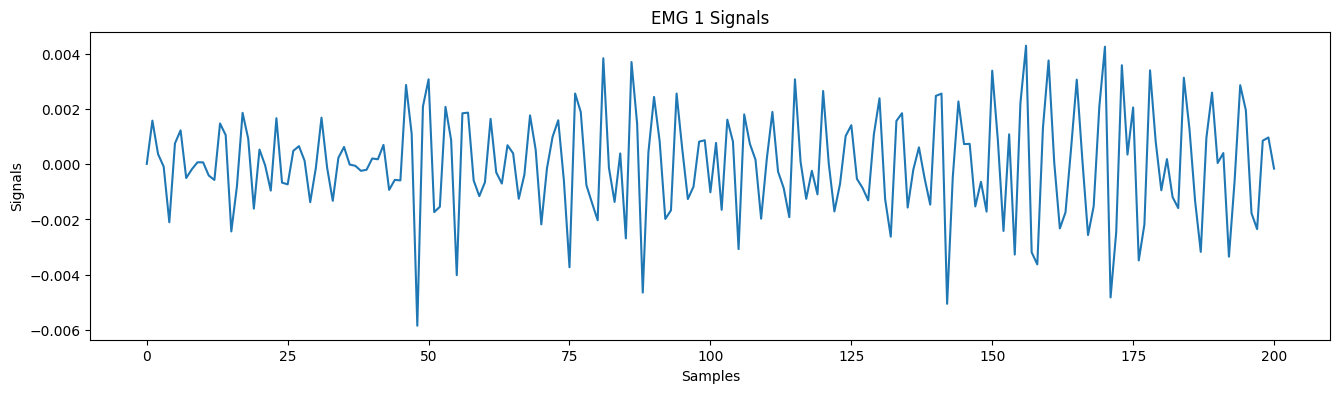

In [14]:
plt.figure(figsize=(16,4))
plt.plot(emg_filtered[: 201, 1])
plt.xlabel("Samples")
plt.ylabel("Signals")
plt.title("EMG 1 Signals")
plt.show()

## __BATCHING__

In [16]:
WINDOW = 250

def create_windows(signal):

    windows = []

    for i in range(0, len(signal) - WINDOW, WINDOW):

        windows.append(signal[i : i + WINDOW])

    return np.array(windows)

In [17]:
batches = create_windows(emg_filtered)
print(batches.shape)

(1924, 250, 10)


In [18]:
label_batches = create_windows(emg_labels)
print(label_batches)
print(label_batches.shape)

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [7 7 7 ... 7 7 7]
 [7 7 7 ... 7 7 7]
 [7 7 7 ... 7 7 7]]
(1924, 250)


## __SERIALIZATION X_TEST & Y_TEST__
Going back to do this for deployment

In [19]:
from scipy.stats import mode

window_labels = mode(label_batches, axis=1).mode.flatten()

print(window_labels.shape)

(1924,)


In [20]:
labels, counts = np.unique(window_labels, return_counts=True)

print(np.column_stack((labels, counts)))

[[  1 419]
 [  2 392]
 [  3 383]
 [  6 346]
 [  7 384]]


In [21]:
from sklearn.model_selection import train_test_split

X_train_windows, X_test_windows, y_train, y_test = train_test_split(
    batches,
    window_labels,
    test_size=0.2,
    random_state=42,
    stratify=window_labels
)

In [22]:
print(X_train_windows.shape)
print(X_test_windows.shape)
print(y_train.shape)
print(y_test.shape)

(1539, 250, 10)
(385, 250, 10)
(1539,)
(385,)


## __FEATURES__

In [23]:
def mav(emg_baches):
    mav_baches = np.mean(np.abs(emg_baches), axis=1)
    return mav_baches

In [24]:
def rms(emg_batches):
        rms_values = np.sqrt(np.mean(emg_batches**2, axis=1))
        return rms_values

In [25]:
def wl(emg_batches):
    wave_length = np.sum(np.abs(np.diff(emg_batches, axis=1)), axis=1)
    return wave_length

In [26]:
def zc(emg_batches, threshold=0):
    diff = emg_batches[:, :-1, :] * emg_batches[:, 1:, :]
    zero_crossings = np.sum(diff < threshold, axis=1)
    return zero_crossings

In [27]:
def ssc(emg_batches, threshold=0):
    diff1 = emg_batches[:, 1:-1, :] - emg_batches[:, :-2, :]

    diff2 = emg_batches[:, 1:-1, :] - emg_batches[:, 2:, :]

    ssc = diff1 * diff2

    slope_sign_changes = np.sum(ssc > threshold, axis=1)

    return slope_sign_changes

In [28]:
def variance(emg_batches):
    var = np.var(emg_batches, ddof=1, axis=1)

    return var

In [30]:
def extracting_features(emg_windows):
    mav_features = mav(emg_windows)
    rms_features = rms(emg_windows)
    wl_features = wl(emg_windows)
    zc_features = zc(emg_windows)
    ssc_features = ssc(emg_windows)
    variance_features = variance(emg_windows)

    all_features = np.hstack(
        [
            mav_features,
            rms_features,
            wl_features,
            zc_features,
            ssc_features,
            variance_features,
        ]
    )

    return all_features

In [31]:
X_train_features = extracting_features(X_train_windows)
X_test_features = extracting_features(X_test_windows)

In [35]:
print(X_train_features[0])
print(X_test_features[0])
print(X_train_features[0].shape)
print(X_train_features.shape)
print(X_test_features.shape)

[7.59742309e-04 6.85688189e-04 2.57453429e-04 8.97799462e-05
 1.97267274e-04 1.18594859e-03 3.84638922e-03 1.23372097e-03
 1.03383886e-04 8.78501948e-04 9.66438302e-04 1.33147251e-03
 4.72729785e-04 2.23652708e-04 3.77141765e-04 1.51315996e-03
 5.03568847e-03 1.91659540e-03 3.69664768e-04 1.46250476e-03
 3.00905138e-01 2.65556484e-01 1.02603167e-01 3.59989858e-02
 7.88203198e-02 4.32060382e-01 1.45234540e+00 4.38267928e-01
 3.93212052e-02 3.02110430e-01 1.50000000e+02 1.83000000e+02
 1.99000000e+02 2.03000000e+02 1.93000000e+02 1.24000000e+02
 1.44000000e+02 1.33000000e+02 2.11000000e+02 1.43000000e+02
 1.62000000e+02 1.87000000e+02 2.08000000e+02 2.04000000e+02
 2.03000000e+02 1.26000000e+02 1.57000000e+02 1.41000000e+02
 2.15000000e+02 1.61000000e+02 9.37652001e-07 1.77988710e-06
 2.24363349e-07 5.02210353e-08 1.42806156e-07 2.29882547e-06
 2.54599646e-05 3.68806524e-06 1.37200688e-07 2.14750121e-06]
[1.19956607e-02 8.23408405e-03 6.93336873e-03 1.21204909e-03
 7.18705087e-04 7.55038

ML

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_features)
X_test = scaler.transform(X_test_features)

In [47]:
print(X_train[1])

[-0.55138395 -0.8281813   0.59112961  0.90902169  0.05290061 -0.36187061
  0.01880868  0.85824505  1.22551286  1.18348488 -0.57535317 -0.79708145
  0.59028075  0.94323572 -0.00828725 -0.3732992  -0.05900633  0.62813402
  1.18571335  1.18518492 -0.53904388 -0.85305883  0.56196183  0.93643318
  0.08013902 -0.38776967 -0.02405687  0.77023977  1.19646841  1.01598304
  0.30392006  0.38085008 -0.42024787 -0.1706157  -0.66241412 -0.31689355
 -0.33461086  1.06604554 -0.70976535 -0.1151277  -0.23938084  0.36213727
 -0.03075571 -0.06600956 -0.50929383 -0.49672336 -1.058613   -0.25106024
 -0.89609238 -0.35260674 -0.54229247 -0.50622321  0.12096984  0.36791526
 -0.10196954 -0.25028711 -0.27797222  0.26561475  0.7216857   0.79176971]


In [48]:
print(X_train[1].shape)

(60,)


In [49]:
params = {
    "kernel": ["rbf"],
    "C": [10, 15, 20, 25, 50, 75, 100],
    "gamma": [0.1, 0.5, 1, 5, 20, 50, 100, 200],
}

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svc = GridSearchCV(estimator=SVC(), param_grid=params, cv=10, scoring="accuracy")
#svc = SVC(**params)

In [51]:
svc.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [10, 15, ...], 'gamma': [0.1, 0.5, ...], 'kernel': ['rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [52]:
pred = svc.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7844155844155845


In [55]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       0.71      0.73      0.72        84
           2       0.81      0.81      0.81        78
           3       0.79      0.74      0.77        77
           6       0.79      0.78      0.79        69
           7       0.83      0.87      0.85        77

    accuracy                           0.78       385
   macro avg       0.79      0.79      0.79       385
weighted avg       0.78      0.78      0.78       385



In [1]:
poly_params = {
    "kernel": ["poly"],
    "C": [10, 15, 20, 25, 50, 75, 100],
    "gamma": [0.1, 0.5, 1, 5, 20],
    "degree": [0.1, 1, 5, 10, 15]

}

In [2]:
poly_svc = GridSearchCV(estimator=SVC(), param_grid=poly_params, cv=10, scoring="accuracy")

NameError: name 'GridSearchCV' is not defined

In [ ]:
poly_svc.fit(X_train, y_train)

In [ ]:
poly_pred = poly_svc.predict(X_test)